## CAD-Recode Demonstration
In this demonstration, we load a point cloud and process it using a pre-trained CAD-Recode model, which generates Python CadQuery code. Finally, we interpret the code to create a CAD model, visualize it, and evaluate its quality metrics. This notebook works on both CPU and GPU.

### Define CAD-Recode model

In [1]:
import open3d
import trimesh
import skimage.io
import numpy as np
import cadquery as cq
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

import torch
from torch import nn
from transformers import (
    AutoTokenizer, Qwen2ForCausalLM, Qwen2Model, PreTrainedModel)
from transformers.modeling_outputs import CausalLMOutputWithPast
from pytorch3d.ops import sample_farthest_points


class FourierPointEncoder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        frequencies = 2.0 ** torch.arange(8, dtype=torch.float32)
        self.register_buffer('frequencies', frequencies, persistent=False)
        self.projection = nn.Linear(51, hidden_size)

    def forward(self, points):
        x = points
        x = (x.unsqueeze(-1) * self.frequencies).view(*x.shape[:-1], -1)
        x = torch.cat((points, x.sin(), x.cos()), dim=-1)
        x = self.projection(x)
        return x


class CADRecode(Qwen2ForCausalLM):
    def __init__(self, config):
        PreTrainedModel.__init__(self, config)
        self.model = Qwen2Model(config)
        self.vocab_size = config.vocab_size
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)

        torch.set_default_dtype(torch.float32)
        self.point_encoder = FourierPointEncoder(config.hidden_size)
        torch.set_default_dtype(torch.bfloat16)

    def forward(self,
                input_ids=None,
                attention_mask=None,
                point_cloud=None,
                position_ids=None,
                past_key_values=None,
                inputs_embeds=None,
                labels=None,
                use_cache=None,
                output_attentions=None,
                output_hidden_states=None,
                return_dict=None,
                cache_position=None):
        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        # concatenate point and text embeddings
        if past_key_values is None or past_key_values.get_seq_length() == 0:
            assert inputs_embeds is None
            inputs_embeds = self.model.embed_tokens(input_ids)
            point_embeds = self.point_encoder(point_cloud).bfloat16()
            inputs_embeds[attention_mask == -1] = point_embeds.reshape(-1, point_embeds.shape[2])
            attention_mask[attention_mask == -1] = 1
            input_ids = None
            position_ids = None

        # decoder outputs consists of (dec_features, layer_state, dec_hidden, dec_attn)
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            position_ids=position_ids,
            past_key_values=past_key_values,
            inputs_embeds=inputs_embeds,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
            cache_position=cache_position)

        hidden_states = outputs[0]
        logits = self.lm_head(hidden_states)
        logits = logits.float()

        loss = None
        if labels is not None:
            # Shift so that tokens < n predict n
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            # Flatten the tokens
            loss_fct = nn.CrossEntropyLoss()
            shift_logits = shift_logits.view(-1, self.config.vocab_size)
            shift_labels = shift_labels.view(-1)
            # Enable model parallelism
            shift_labels = shift_labels.to(shift_logits.device)
            loss = loss_fct(shift_logits, shift_labels)

        if not return_dict:
            output = (logits,) + outputs[1:]
            return (loss,) + output if loss is not None else output

        return CausalLMOutputWithPast(
            loss=loss,
            logits=logits,
            past_key_values=outputs.past_key_values,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions)

    def prepare_inputs_for_generation(self, *args, **kwargs):
        model_inputs = super().prepare_inputs_for_generation(*args, **kwargs)
        model_inputs['point_cloud'] = kwargs['point_cloud']
        return model_inputs

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### Load CAD-Recode checkpoint

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
attn_implementation = 'flash_attention_2' if torch.cuda.is_available() else None
tokenizer = AutoTokenizer.from_pretrained(
    'Qwen/Qwen2-1.5B',
    pad_token='<|im_end|>',
    padding_side='left')
model = CADRecode.from_pretrained(
    'filapro/cad-recode-v1.5',
    torch_dtype='auto',
    attn_implementation=attn_implementation).eval().to(device)

# from peft import PeftModel
# CHECKPOINT_DIR = "Run4/cad-recode-finetuned-final"
# model = CADRecode.from_pretrained(CHECKPOINT_DIR, torch_dtype=torch.bfloat16, trust_remote_code=True).to(device)
# model = PeftModel.from_pretrained(model, CHECKPOINT_DIR)
# model.eval()
# print()

You are attempting to use Flash Attention 2.0 with a model not initialized on GPU. Make sure to move the model to GPU after initializing it on CPU with `model.to('cuda')`.


### Load input point cloud
Load the mesh of one of the examples from the DeepCAD test set and sample 256 points from it. Then input mesh is normalized to fit within a cube of size 2, centered at the origin. Both the mesh and point cloud can be visualized interactively in this notebook using `open3d` or `trimesh`; however, for non-interactive environments, we render them as static images.

In [3]:
#!wget https://github.com/filaPro/cad-recode/releases/download/v1.0/00409751.stl

In [4]:
def mesh_to_point_cloud(mesh, n_points=256, n_pre_points=8192):
    vertices, _ = trimesh.sample.sample_surface(mesh, n_pre_points)
    _, ids = sample_farthest_points(torch.tensor(vertices).unsqueeze(0), K=n_points)
    ids = ids[0].numpy()
    return np.asarray(vertices[ids])


gt_mesh = trimesh.load_mesh('Fusion360/r1.0.1/reconstruction/22432_e4a51ee9_0006.obj')#'./00409751.stl')
gt_mesh.apply_translation(-(gt_mesh.bounds[0] + gt_mesh.bounds[1]) / 2.0)
gt_mesh.apply_scale(2.0 / max(gt_mesh.extents))
np.random.seed(0)
point_cloud = mesh_to_point_cloud(gt_mesh)

### Let's have a look at input point cloud
It looks like a table with four legs!

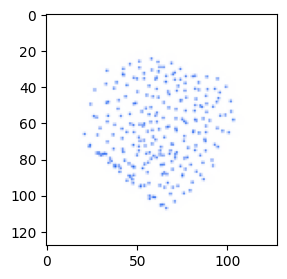

In [5]:
def render(geometry, image_size=128, camera_distance=-1.8, image_path='/tmp/tmp.png'):
    visualizer = open3d.visualization.Visualizer()
    visualizer.create_window(width=image_size * 4, height=image_size * 4)
    visualizer.add_geometry(geometry)

    lookat = np.array([0, 0, 0], dtype=np.float32)
    front = np.array([1, 1, 1], dtype=np.float32)
    up = np.array([0, 1, 0], dtype=np.float32)
    eye = lookat + front * camera_distance
    right = np.cross(up, front)
    right /= np.linalg.norm(right)
    true_up = np.cross(front, right)
    rotation_matrix = np.column_stack((right, true_up, front)).T
    extrinsic = np.eye(4)
    extrinsic[:3, :3] = rotation_matrix
    extrinsic[:3, 3] = -rotation_matrix @ eye

    view_control = visualizer.get_view_control()
    camera_params = view_control.convert_to_pinhole_camera_parameters()
    camera_params.extrinsic = extrinsic
    view_control.convert_from_pinhole_camera_parameters(camera_params)

    visualizer.poll_events()
    visualizer.update_renderer()
    visualizer.capture_screen_image(image_path)
    visualizer.destroy_window()

    image = skimage.io.imread(image_path)
    image = skimage.transform.resize(
        image,
        output_shape=(image_size, image_size),
        order=2,
        anti_aliasing=True,
        preserve_range=True).astype(np.uint8)
    return image

pcd = open3d.geometry.PointCloud()
pcd.points = open3d.utility.Vector3dVector(point_cloud)
pcd.paint_uniform_color(np.array([0, 80, 239]) / 255)
plt.figure(figsize=(3, 3))
_ = plt.imshow(render(pcd))

### Run CAD-Recode on the input point cloud

In [6]:
input_ids = [tokenizer.pad_token_id] * len(point_cloud) + [tokenizer('<|im_start|>')['input_ids'][0]]
attention_mask = [-1] * len(point_cloud) + [1]

print(f"{point_cloud=}")


with torch.no_grad():
    batch_ids = model.generate(
        input_ids=torch.tensor(input_ids).unsqueeze(0).to(model.device),
        attention_mask=torch.tensor(attention_mask).unsqueeze(0).to(model.device),
        point_cloud=torch.tensor(point_cloud.astype(np.float32)).unsqueeze(0).to(model.device),
        max_new_tokens=768,
        pad_token_id=tokenizer.pad_token_id)
py_string = tokenizer.batch_decode(batch_ids)[0]
begin = py_string.find('<|im_start|>') + 12
end = py_string.find('<|endoftext|>')
py_string = py_string[begin: end]
print(py_string)

point_cloud=array([[-0.09366499, -0.86602578, -0.00364342],
       [ 0.50335693,  0.86020733,  0.67708113],
       [-0.59153044,  0.69887834, -0.68759844],
       [ 0.90248056,  0.16891094, -0.68517077],
       [-0.88668543,  0.19626453,  0.68754181],
       [ 0.79188287, -0.3604688 ,  0.6828737 ],
       [-0.79763519, -0.35050688, -0.64486697],
       [ 0.29369643,  0.86602652, -0.31197453],
       [ 0.5792285 , -0.7288002 , -0.63836104],
       [ 0.01289763,  0.10344513,  0.43562992],
       [-0.44923403,  0.86602368,  0.23385535],
       [ 0.0028962 ,  0.05143988, -0.53405514],
       [-0.62717487, -0.64575023,  0.6842063 ],
       [ 0.81420355,  0.32180987,  0.13568311],
       [-0.88169873,  0.20490182, -0.09317257],
       [ 0.19935659, -0.86492939,  0.68759844],
       [-0.16701774, -0.68260897, -0.68759844],
       [ 0.60749659, -0.679838  ,  0.06994825],
       [-0.68775293, -0.54082687,  0.0041616 ],
       [-0.07994138,  0.67106052,  0.68759844],
       [ 0.55770385,  0.2183

### Execute predicted python code to raise a CAD model
The predicted code might be invalid or could potentially cause memory leaks in CadQuery, as described in this [issue](https://github.com/CadQuery/cadquery/issues/1665).  Therefore, it is recommended to run the next cell in a separate process with a timeout of, for example, 3 seconds.:
```
process = Process(target=..., args=...)
process.start()
process.join(3)

if process.is_alive():
    process.terminate()
    process.join()
```
But in this demo safety is omitted.

In [7]:
import os

if os.path.isfile('/tmp/1.stl'):
    os.remove('/tmp/1.stl')

exec(py_string, globals())
compound = globals()['r'].val()
vertices, faces = compound.tessellate(0.001, 0.1)
mesh = trimesh.Trimesh([(v.x, v.y, v.z) for v in vertices], faces)
mesh.export('/tmp/1.stl')
cq.exporters.export(compound, '/tmp/1.step')
MESH_CREATED = True

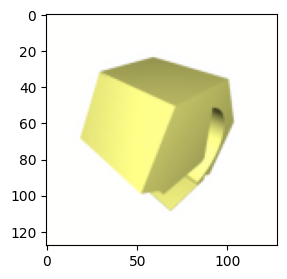

In [8]:
mesh = open3d.io.read_triangle_mesh('/tmp/1.stl')
mesh.vertices = open3d.utility.Vector3dVector(np.asarray(mesh.vertices) / 100.)
mesh.paint_uniform_color(np.array([255, 255, 136]) / 255)
mesh.compute_vertex_normals()
plt.figure(figsize=(3, 3))
_ = plt.imshow(render(mesh))

### Compute IoU and Chamfer distance metrics
The predicted model resembles a table, but let's calculate how closely it matches the ground truth mesh.

In [9]:
pred_mesh = trimesh.load_mesh('/tmp/1.stl')
if MESH_CREATED:
    pred_mesh.apply_transform(trimesh.transformations.scale_matrix(1 / 100 / 2))
    pred_mesh.apply_transform(trimesh.transformations.translation_matrix([0.5, 0.5, 0.5]))
    gt_mesh.apply_transform(trimesh.transformations.scale_matrix(1 / 2))
    gt_mesh.apply_transform(trimesh.transformations.translation_matrix([0.5, 0.5, 0.5]))
    MESH_CREATED = False

n_points = 8192
gt_points, _ = trimesh.sample.sample_surface(gt_mesh, n_points, seed=0)
pred_points, _ = trimesh.sample.sample_surface(pred_mesh, n_points, seed=0)
gt_distance, _ = cKDTree(gt_points).query(pred_points, k=1)
pred_distance, _ = cKDTree(pred_points).query(gt_points, k=1)
cd = np.mean(np.square(gt_distance)) + np.mean(np.square(pred_distance))

intersection_volume = 0
for gt_mesh_i in gt_mesh.split():
    for pred_mesh_i in pred_mesh.split():
        intersection = gt_mesh_i.intersection(pred_mesh_i)
        volume = intersection.volume if intersection is not None else 0
        intersection_volume += volume

gt_volume = sum(m.volume for m in gt_mesh.split())
pred_volume = sum(m.volume for m in pred_mesh.split())
union_volume = gt_volume + pred_volume - intersection_volume
iou = intersection_volume / union_volume

print(f'CD: {cd * 1000:.6f}, IoU: {iou:.6f}')

CD: 4.189895, IoU: 0.000000


In [10]:
#pred_mesh.show()

In [11]:
results = dict(
    original={"CD": 0.283105, "IoU": 0.943088},
)

In [31]:
import json, os
import numpy as np
import torch
import trimesh
from pytorch3d.ops import sample_farthest_points

class Fusion360EvalDataset(torch.utils.data.Dataset):
    def __init__(self, fusion360_root: str, num_points: int = 256, num_pre_points: int = 8192) -> None:
        self.data = []
        with open(os.path.join(fusion360_root, f"train_test.json"), 'r') as f:
            uuid_list = json.load(f)["test"]
        for uuid in uuid_list:
            self.data.append({
                "uuid": uuid,
                "gt_mesh": os.path.join(fusion360_root, "reconstruction", f"{uuid}.obj"),
            })

        self.data.sort(key=lambda d: d["uuid"]) # Sort by uuid
        self.num_points = num_points
        self.num_pre_points = num_pre_points

    @staticmethod
    def mesh_to_point_cloud(mesh, n_points: int, n_pre_points: int, seed: int = 0):
        vertices, _ = trimesh.sample.sample_surface(mesh, n_pre_points, seed=seed)
        if len(vertices) < n_points:
            raise ValueError(f"Mesh doesn't have enough vertices: {len(vertices)}=")

        if n_pre_points == n_points: # If sampling exactly n_points, FPS is not needed
            ids = np.arange(n_points)
        else:
            # Ensure vertices tensor is float32 for FPS
            _, ids = sample_farthest_points(torch.tensor(vertices, dtype=torch.float32).unsqueeze(0), K=n_points)
            ids = ids[0].numpy()

        sampled_points = np.asarray(vertices[ids], dtype=np.float32)
        return sampled_points

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int):
        data = self.data[idx]
        uuid = data["uuid"]

        # load GT mesh
        gt_mesh = trimesh.load_mesh(data["gt_mesh"])
        if isinstance(gt_mesh, trimesh.Scene): # Handle scenes if necessary
            print(f"Warning: Loaded a trimesh.Scene for {uuid}. Attempting to extract geometry.")
            # Simple approach: combine all geometries
            gt_mesh = gt_mesh.dump(concatenate=True)
            if not isinstance(gt_mesh, trimesh.Trimesh) or len(gt_mesh.vertices) == 0:
                raise ValueError(f"Warning: Loaded empty or invalid mesh for UUID {uuid}.")

        # normalize mesh
        center = gt_mesh.bounds[0] + (gt_mesh.bounds[1] - gt_mesh.bounds[0]) / 2.0
        gt_mesh.apply_translation(-center)
        scale = 2.0 / max(gt_mesh.extents) if max(gt_mesh.extents) > 1e-6 else 1.0 # Avoid division by zero
        gt_mesh.apply_scale(scale)

        # sample points
        point_cloud = self.mesh_to_point_cloud(gt_mesh, self.num_points, self.num_pre_points)
        if point_cloud is None:
            RuntimeError(f"Failed to generate point cloud for: {uuid}")

        return {
            "uuid": uuid,
            "point_cloud": point_cloud,
            "gt_mesh": gt_mesh,
        }

# fusion360_dataset = Fusion360EvalDataset("Fusion360/r1.0.1")
# data = fusion360_dataset[4]
# gt_mesh = data["gt_mesh"]

In [32]:
import cadquery as cq
w0=cq.Workplane('ZX',origin=(0,100,0))
r=w0.sketch().segment((-5,-5),(5,-5)).segment((5,5)).segment((-5,5)).segment((-5,0)).arc((0,-5),(-5,-2)).close().assemble().finalize().extrude(-200)

vertices, faces = r.val().tessellate(0.001, 0.1)
pred_mesh = trimesh.Trimesh([(v.x, v.y, v.z) for v in vertices], faces)
pred_mesh.apply_transform(trimesh.transformations.scale_matrix(1 / 100 / 2))
pred_mesh.apply_transform(trimesh.transformations.translation_matrix([0.5, 0.5, 0.5]))

gt_mesh.apply_transform(trimesh.transformations.scale_matrix(1 / 2))
gt_mesh.apply_transform(trimesh.transformations.translation_matrix([0.5, 0.5, 0.5]))

intersection_volume = 0
for gt_mesh_i in gt_mesh.split():
    for pred_mesh_i in pred_mesh.split():
        intersection = gt_mesh_i.intersection(pred_mesh_i)
        volume = intersection.volume if intersection is not None else 0
        intersection_volume += volume

gt_volume = sum(m.volume for m in gt_mesh.split())
pred_volume = sum(m.volume for m in pred_mesh.split())
union_volume = gt_volume + pred_volume - intersection_volume

print(f"{gt_volume=}, {pred_volume=}, {union_volume=}, {intersection_volume=}")
iou = intersection_volume / union_volume

gt_volume=np.float64(0.0), pred_volume=0, union_volume=np.float64(0.0), intersection_volume=0


/tmp/ipykernel_2858995/3161662831.py:25: RuntimeWarning: invalid value encountered in scalar divide
  iou = intersection_volume / union_volume


In [11]:
def mesh_to_point_cloud(mesh, n_points=256, n_pre_points=8192):
    vertices, _ = trimesh.sample.sample_surface(mesh, n_pre_points)
    _, ids = sample_farthest_points(torch.tensor(vertices).unsqueeze(0), K=n_points)
    ids = ids[0].numpy()
    return np.asarray(vertices[ids])


gt_mesh = trimesh.load_mesh('./00409751.stl')
gt_mesh.apply_translation(-(gt_mesh.bounds[0] + gt_mesh.bounds[1]) / 2.0)
gt_mesh.apply_scale(2.0 / max(gt_mesh.extents))
np.random.seed(0)
point_cloud = mesh_to_point_cloud(gt_mesh)

mydata = [{
    "uuid": 123,
    "point_cloud": point_cloud,
    "gt_mesh": gt_mesh,
}]

eval_summary = {}

for i, data in enumerate(mydata):
    uuid = data["uuid"]
    point_cloud = data["point_cloud"]
    gt_mesh = data["gt_mesh"]

    input_ids = [tokenizer.pad_token_id] * len(point_cloud) + [tokenizer('<|im_start|>')['input_ids'][0]]
    attention_mask = [-1] * len(point_cloud) + [1]
    with torch.no_grad():
        batch_ids = model.generate(
            input_ids=torch.tensor(input_ids).unsqueeze(0).to(model.device),
            attention_mask=torch.tensor(attention_mask).unsqueeze(0).to(model.device),
            point_cloud=torch.tensor(point_cloud.astype(np.float32)).unsqueeze(0).to(model.device),
            max_new_tokens=768,
            pad_token_id=tokenizer.pad_token_id)
    py_string = tokenizer.batch_decode(batch_ids)[0]
    begin = py_string.find('<|im_start|>') + 12
    end = py_string.find('<|endoftext|>')
    py_string = py_string[begin: end]
    print("Output:", py_string)

    try:
        exec(py_string, globals())
        compound = globals()['r'].val()
        vertices, faces = compound.tessellate(0.001, 0.1)
        pred_mesh = trimesh.Trimesh([(v.x, v.y, v.z) for v in vertices], faces)

        pred_mesh.apply_transform(trimesh.transformations.scale_matrix(1 / 100 / 2))
        pred_mesh.apply_transform(trimesh.transformations.translation_matrix([0.5, 0.5, 0.5]))
        gt_mesh.apply_transform(trimesh.transformations.scale_matrix(1 / 2))
        gt_mesh.apply_transform(trimesh.transformations.translation_matrix([0.5, 0.5, 0.5]))

        n_points = 8192
        gt_points, _ = trimesh.sample.sample_surface(gt_mesh, n_points, seed=0)
        pred_points, _ = trimesh.sample.sample_surface(pred_mesh, n_points, seed=0)

        gt_distance, _ = cKDTree(gt_points).query(pred_points, k=1)
        pred_distance, _ = cKDTree(pred_points).query(gt_points, k=1)
        cd = np.mean(np.square(gt_distance)) + np.mean(np.square(pred_distance))

        intersection_volume = 0
        for gt_mesh_i in gt_mesh.split():
            for pred_mesh_i in pred_mesh.split():
                if gt_mesh_i.volume > 1e-8:
                    intersection = gt_mesh_i.intersection(pred_mesh_i)
                else:
                    intersection = None
                volume = intersection.volume if intersection is not None else 0
                intersection_volume += volume

        gt_volume = sum(m.volume for m in gt_mesh.split())
        pred_volume = sum(m.volume for m in pred_mesh.split())
        union_volume = gt_volume + pred_volume - intersection_volume
        if union_volume > 1e-8:
            iou = intersection_volume / union_volume
        else:
            iou = None

        eval_summary[uuid] = {"CD": cd * 1000, "IoU": iou, "pred": py_string}

    except Exception as e:
        print("Error:", e)
        eval_summary[uuid] = {"CD": None, "IoU": None, "pred": py_string}
        continue

    if i >= 5: break

print(f"{eval_summary=}")


Output: import cadquery as cq
w0=cq.Workplane('XY',origin=(0,0,88))
r=w0.sketch().segment((-98,-100),(-77,-99)).arc((-78,-89),(-77,-79)).segment((-98,-79)).close().assemble().reset().face(w0.sketch().segment((-98,78),(-76,78)).segment((-75,100)).segment((-98,100)).close().assemble()).reset().face(w0.sketch().segment((78,-99),(98,-99)).segment((98,-79)).segment((78,-79)).arc((79,-89),(78,-99)).assemble()).reset().face(w0.sketch().arc((78,82),(88,82),(98,80)).segment((98,100)).segment((78,100)).close().assemble()).finalize().extrude(-177).union(w0.workplane(offset=-15/2).box(196,200,15))
eval_summary={123: {'CD': np.float64(0.28497994044219915), 'IoU': np.float64(0.943087549792558), 'pred': "import cadquery as cq\nw0=cq.Workplane('XY',origin=(0,0,88))\nr=w0.sketch().segment((-98,-100),(-77,-99)).arc((-78,-89),(-77,-79)).segment((-98,-79)).close().assemble().reset().face(w0.sketch().segment((-98,78),(-76,78)).segment((-75,100)).segment((-98,100)).close().assemble()).reset().face(w0.sketch

In [ ]:
import cadquery as cq
w0=cq.Workplane('XY',origin=(0,0,88))
r=w0.sketch().segment((-98,-100),(-77,-99)).arc((-78,-89),(-77,-79)).segment((-98,-79)).close().assemble().reset().face(w0.sketch().segment((-98,78),(-76,78)).segment((-75,100)).segment((-98,100)).close().assemble()).reset().face(w0.sketch().segment((78,-99),(98,-99)).segment((98,-79)).segment((78,-79)).arc((79,-89),(78,-99)).assemble()).reset().face(w0.sketch().arc((78,82),(88,82),(98,80)).segment((98,100)).segment((78,100)).close().assemble()).finalize().extrude(-177).union(w0.workplane(offset=-15/2).box(196,200,15))